PCA 作为基变换
特征值: [59.42709128  1.22623354]
主成分方向:
[[-0.85109474  0.52501214]
 [-0.52501214 -0.85109474]]

在新基下的协方差矩阵:
[[59.427 -0.   ]
 [-0.     1.226]]
是对角阵？ True


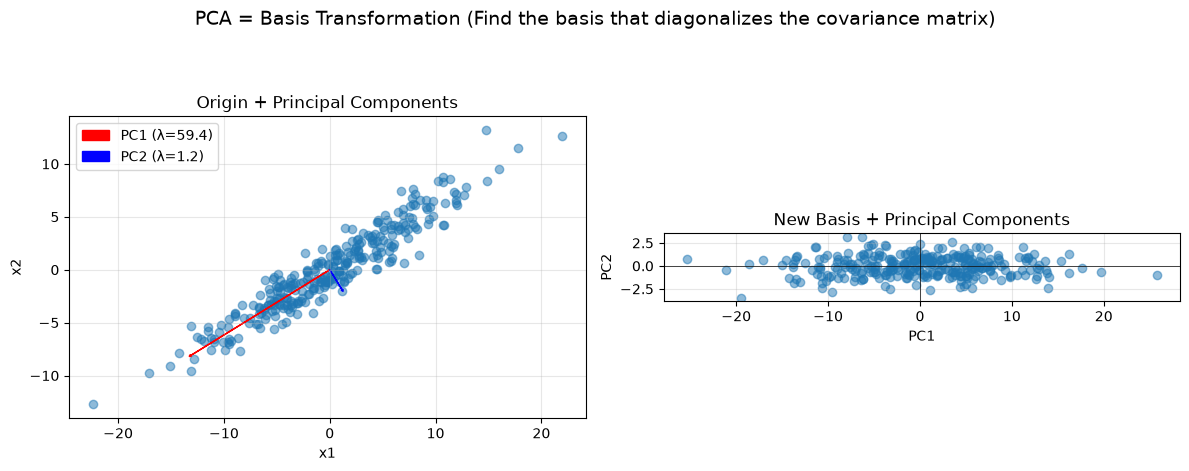

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ---- 生成数据 ----
X, _ = make_blobs(n_samples=300, centers=1, n_features=2,
                  cluster_std=3, random_state=42)
X = X @ np.array([[2, 1], [1, 1]])  # 拉伸数据

print("=" * 60)
print("PCA 作为基变换")
print("=" * 60)

# ---- 中心化 ----
X_centered = X - np.mean(X, axis=0)

# ---- PCA：找新基 ----
cov = np.cov(X_centered.T)
eigvals, eigvecs = np.linalg.eigh(cov)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]  # 主成分方向（新基）

print(f"特征值: {eigvals}")
print(f"主成分方向:\n{eigvecs}")

# ---- 在新基下表示数据 ----
X_pca = X_centered @ eigvecs  # 投影到新基

# ---- 验证协方差在新基下是对角阵 ----
cov_pca = np.cov(X_pca.T)
print(f"\n在新基下的协方差矩阵:\n{cov_pca.round(3)}")
print(f"是对角阵？ {np.allclose(cov_pca - np.diag(np.diag(cov_pca)), 0, atol=1e-6)}")

# ---- 可视化 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 原始数据 + 主成分方向
axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5)
for i in range(2):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i]) * 2
    axes[0].arrow(0, 0, vec[0], vec[1], 
                 head_width=0.2, head_length=0.2,
                 fc='red' if i==0 else 'blue',
                 ec='red' if i==0 else 'blue',
                 label=f'PC{i+1} (λ={eigvals[i]:.1f})')
axes[0].set_title('Origin + Principal Components')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_aspect('equal')

# 在新基下的数据
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
# axes[1].set_title('在新基下：各方向独立（协方差对角化）')
axes[1].set_title('New Basis + Principal Components')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.3)
axes[1].set_aspect('equal')

# plt.suptitle('PCA = 基变换（找协方差矩阵对角化的基）', fontsize=14)
plt.suptitle('PCA = Basis Transformation (Find the basis that diagonalizes the covariance matrix)', fontsize=14)
plt.tight_layout()
plt.show()